# 02 — EDA: Heat Trends

Question: how much hotter has the UK got, and where is the night-time signal strongest?

In [1]:
import sys; sys.path.insert(0, '..')
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
monthly = pd.read_parquet('../data/processed/metoffice_monthly.parquet')
monthly.head()


,year,month,value,month_num,date,variable,region
0,1884,jan,7.3,1,1884-01-01,tmax,UK
1,1884,feb,6.8,2,1884-02-01,tmax,UK
2,1884,mar,8.5,3,1884-03-01,tmax,UK
3,1884,apr,10.1,4,1884-04-01,tmax,UK
4,1884,may,14.5,5,1884-05-01,tmax,UK


## Summer Tmax — decadal trend per region

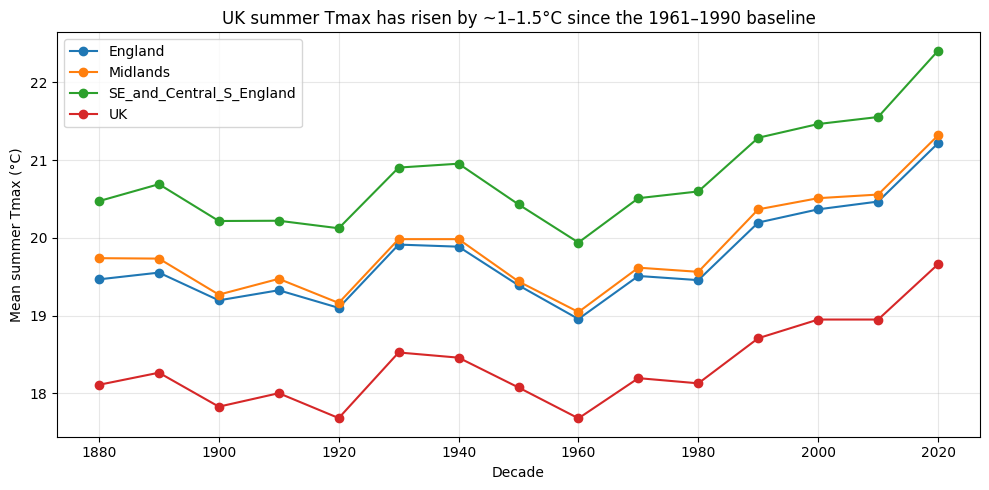

In [2]:
summer = monthly[(monthly.variable == 'tmax') & (monthly.month.isin(['jun','jul','aug']))]
annual = summer.groupby(['region','year'])['value'].mean().reset_index()
annual['decade'] = (annual['year']//10)*10
decadal = annual.groupby(['region','decade'])['value'].mean().reset_index()
fig, ax = plt.subplots(figsize=(10,5))
for reg, g in decadal.groupby('region'):
    ax.plot(g.decade, g.value, marker='o', label=reg)
ax.set_xlabel('Decade'); ax.set_ylabel('Mean summer Tmax (°C)')
ax.set_title('UK summer Tmax has risen by ~1–1.5°C since the 1961–1990 baseline')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout()


## The night-time signal (Tmin) — health-relevant
Night-time minimum temperatures matter more for overheating-attributed mortality than daytime maxima — homes that can't cool down between heatwave days are where excess deaths concentrate.

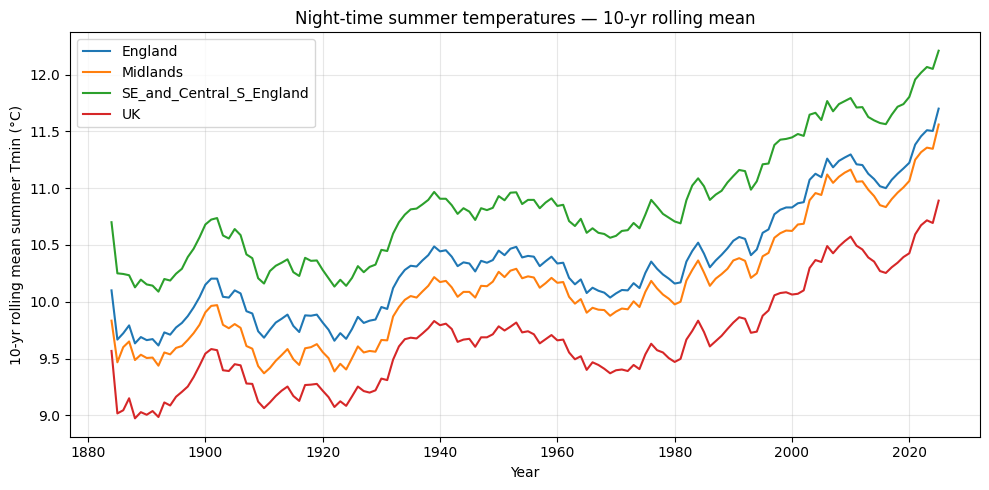

In [3]:
tmin = monthly[(monthly.variable == 'tmin') & (monthly.month.isin(['jun','jul','aug']))]
tmin_a = tmin.groupby(['region','year'])['value'].mean().reset_index()
fig, ax = plt.subplots(figsize=(10,5))
for reg, g in tmin_a.groupby('region'):
    ax.plot(g.year, g['value'].rolling(10, min_periods=1).mean(), label=reg)
ax.set_xlabel('Year'); ax.set_ylabel('10-yr rolling mean summer Tmin (°C)')
ax.set_title('Night-time summer temperatures — 10-yr rolling mean')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout()


## How much have we warmed since baseline?

In [4]:
base = summer[summer.year.between(1961,1990)].groupby('region')['value'].mean().rename('baseline')
recent = summer[summer.year.between(2014,2024)].groupby('region')['value'].mean().rename('recent')
diff = pd.concat([base, recent], axis=1).assign(delta_c = lambda d: d.recent - d.baseline).round(2)
diff.sort_values('delta_c', ascending=False)


,baseline,recent,delta_c
region,,,
SE_and_Central_S_England,20.41,22.06,1.65
England,19.35,20.87,1.52
Midlands,19.45,20.94,1.49
UK,18.03,19.31,1.29
